# Scikit-Learn Regression Workflow

## Objective

Build a multiple linear regression model to predict `Performance Index`
using a reproducible Scikit-Learn workflow.

The workflow includes:

- Feature / target separation
- Train / test split
- Numerical and categorical preprocessing
- One-hot encoding
- ColumnTransformer
- Pipeline
- LinearRegression
- Cross-validation
- Final test evaluation
- Residual analysis

In [9]:
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [4]:
# Load the raw data again:
df = pd.read_csv(
    '../data/raw/Student_Performance.csv',
    engine='pyarrow',
    dtype_backend='pyarrow'    
    )

df.head()   

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


# 1. Separate predictors $X$ and target $y$

In [5]:
TARGET = "Performance Index"

X = df.drop(columns=TARGET)
y = df[TARGET]

In [6]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 5)
y shape: (10000,)


# 2. Train/Test Split

In [11]:
y_bins = pd.qcut(
    y,
    q=5,
    labels=False
)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_bins
)

In [13]:
print("Full:")
print(y.describe())

print("\nTrain:")
print(y_train.describe())

print("\nTest:")
print(y_test.describe())

Full:
count      10000.0
mean       55.2248
std      19.212558
min           10.0
25%           40.0
50%           55.0
75%           71.0
max          100.0
Name: Performance Index, dtype: double[pyarrow]

Train:
count       8000.0
mean      55.14475
std      19.186364
min           10.0
25%           40.0
50%           55.0
75%           70.0
max          100.0
Name: Performance Index, dtype: double[pyarrow]

Test:
count       2000.0
mean        55.545
std      19.318478
min           11.0
25%           40.0
50%           56.0
75%           71.0
max          100.0
Name: Performance Index, dtype: double[pyarrow]


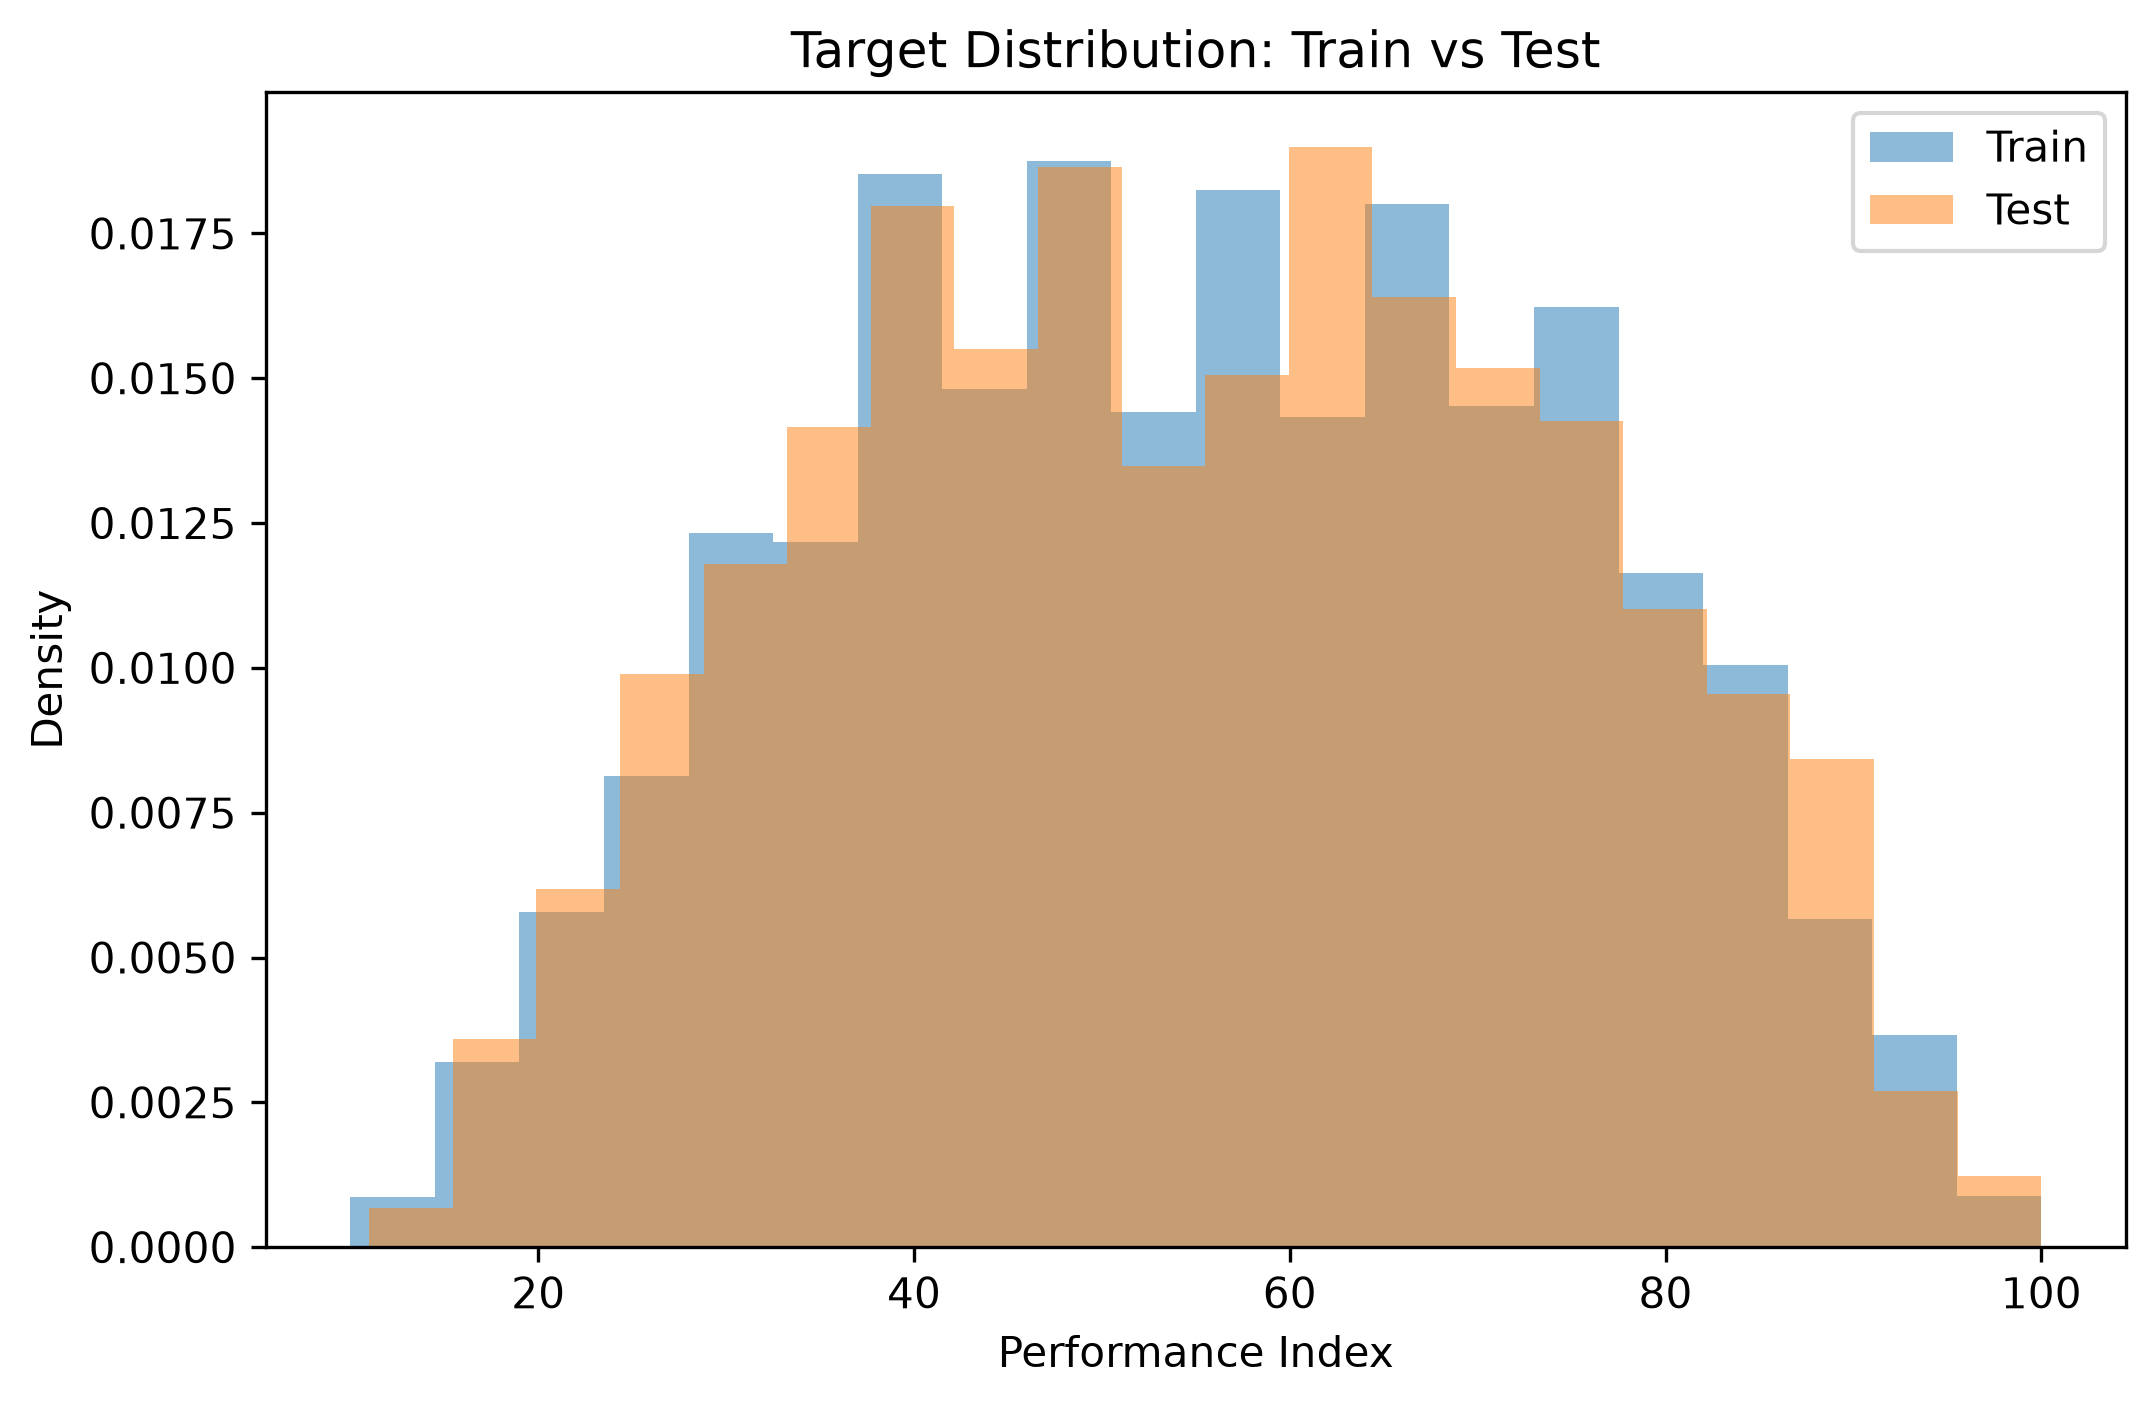

In [14]:
plt.figure(figsize=(8, 5), dpi=300)

plt.hist(
    y_train,
    bins=20,
    density=True,
    alpha=0.5,
    label="Train"
)

plt.hist(
    y_test,
    bins=20,
    density=True,
    alpha=0.5,
    label="Test"
)

plt.xlabel("Performance Index")
plt.ylabel("Density")
plt.title("Target Distribution: Train vs Test")
plt.legend()

plt.show()

# 3. One hot encoding for category variable 
### (The same with dummy variables)

In [17]:
# Define feature group
numeric_features = [
    "Hours Studied",
    "Previous Scores",
    "Sleep Hours",
    "Sample Question Papers Practiced"
]

categorical_features = [
    "Extracurricular Activities"
]

In [ ]:

# learn how OneHotEncoder work in scikit-learn 
# by creating an instance of the OneHotEncoder class and fitting it to the categorical features of the training data. 
# This will allow you to transform the categorical features into a one-hot encoded format, 
# which is suitable for machine learning models.

from sklearn.preprocessing import OneHotEncoder


encoder = OneHotEncoder(
    drop="if_binary",
    handle_unknown="ignore",
    sparse_output=False
)

In [27]:
# Fit the encoder on the training data and transform it to get the encoded categorical features
X_train_cat_encoded = encoder.fit_transform(
    X_train[categorical_features]
)

In [25]:
# inspect the encoder
display(encoder.categories_)
display(encoder.drop_idx_)
display(encoder.get_feature_names_out())
display(X_train_cat_encoded[:10])

[array(['No', 'Yes'], dtype=object)]

array([0], dtype=object)

array(['Extracurricular Activities_Yes'], dtype=object)

array([[1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [28]:
# Only transform the test data using the already fitted encoder
X_test_cat_encoded = encoder.transform(
    X_test[categorical_features]
)

In [29]:
X_train_cat_df = pd.DataFrame(
    X_train_cat_encoded,
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_train.index
)

X_train_cat_df.head()

,Extracurricular Activities_Yes
5840,1.0
4135,1.0
7716,0.0
6314,0.0
903,1.0


# Learn preprocessor


In [ ]:
# Preprocessing pipeline using ColumnTransformer to handle both numerical and categorical features.
# Professional workflow: Use ColumnTransformer to apply different preprocessing steps to different types of features 
# (numerical and categorical) in a single step.

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="if_binary",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

### inspect exactly what our preprocessor does before we hide it inside the Pipeline.

In [ ]:
#  tell the ColumnTransformer to return a Pandas DataFrame instead of a NumPy array:
preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [ ]:
# fit it only on the training set and transform X_train
# fit_transform() method is used to fit the preprocessor on the training data and transform it in one step.

X_train_prepared = preprocessor.fit_transform(X_train)

In [ ]:
# inspect:
X_train_prepared.head()

,num__Hours Studied,num__Previous Scores,num__Sleep Hours,num__Sample Question Papers Practiced,cat__Extracurricular Activities_Yes
5840,0.008723,-1.695443,-0.312459,0.835358,1.0
4135,-1.147983,1.476412,0.275976,0.136570,1.0
7716,0.394292,0.034660,-0.312459,0.485964,0.0
6314,0.008723,-1.522433,0.275976,0.835358,0.0
903,0.394292,-1.061072,0.275976,-0.562219,1.0


In [ ]:
# check the shape of the prepared training data
X_train_prepared.shape

(8000, 5)

In [35]:
# inspect the column names of the prepared training data
X_train_prepared.columns

Index(['num__Hours Studied', 'num__Previous Scores', 'num__Sleep Hours',
       'num__Sample Question Papers Practiced',
       'cat__Extracurricular Activities_Yes'],
      dtype='str')

In [36]:
# check the numerical summaries:
X_train_prepared.describe()

,num__Hours Studied,num__Previous Scores,num__Sleep Hours,num__Sample Question Papers Practiced,cat__Extracurricular Activities_Yes
count,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8000.00000
mean,-1.394440e-16,-5.262457e-17,2.113865e-16,8.704149e-17,0.49875
std,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,0.50003
min,-1.533551e+00,-1.695443e+00,-1.489329e+00,-1.610402e+00,0.00000
25%,-7.624139e-01,-8.880620e-01,-9.008939e-01,-9.116135e-01,0.00000
50%,8.723492e-03,-2.301037e-02,2.759760e-01,1.365695e-01,0.00000
75%,7.798609e-01,8.997114e-01,8.644110e-01,8.353582e-01,1.00000
max,1.550998e+00,1.707093e+00,1.452846e+00,1.534147e+00,1.00000


In [ ]:
# compare raw vs transformed side-by-side:
display(X_train.head())
display(X_train_prepared.head())

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
5840,5,40,Yes,6,7
4135,2,95,Yes,7,5
7716,6,70,No,6,6
6314,5,43,No,7,7
903,6,51,Yes,7,3


,num__Hours Studied,num__Previous Scores,num__Sleep Hours,num__Sample Question Papers Practiced,cat__Extracurricular Activities_Yes
5840,0.008723,-1.695443,-0.312459,0.835358,1.0
4135,-1.147983,1.476412,0.275976,0.136570,1.0
7716,0.394292,0.034660,-0.312459,0.485964,0.0
6314,0.008723,-1.522433,0.275976,0.835358,0.0
903,0.394292,-1.061072,0.275976,-0.562219,1.0


# Learn Regressor

In [38]:
from sklearn.linear_model import SGDRegressor

regressor = SGDRegressor(
    loss="squared_error",
    penalty=None,
    learning_rate="constant",
    eta0=0.01,
    max_iter=1000,
    tol=1e-3,
    shuffle=True,
    random_state=42
)

# Pipeline

In [39]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", regressor)
])

In [40]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Hours Studied','Previous Scores','Extracurricular Activities', 'Sleep Hours','Sample Question Papers Practiced']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automat

In [ ]:
# oneline fit and transform the training data using the pipeline
fitted_regressor = pipeline.named_steps["regressor"]

In [43]:
display(fitted_regressor.n_iter_)
display(fitted_regressor.intercept_)
display(fitted_regressor.coef_)

9

array([54.87494025])

array([ 7.32557884, 17.6359987 ,  0.82681802,  0.67900589,  0.66044748])

#### Inspect only coefficient

In [45]:
# get the transformed feature names:
feature_names = (
    pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_names

array(['num__Hours Studied', 'num__Previous Scores', 'num__Sleep Hours',
       'num__Sample Question Papers Practiced',
       'cat__Extracurricular Activities_Yes'], dtype=object)

In [46]:
# combine them:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": fitted_regressor.coef_
})

coef_df

,Feature,Coefficient
0,num__Hours Studied,7.325579
1,num__Previous Scores,17.635999
2,num__Sleep Hours,0.826818
3,num__Sample Question Papers Practiced,0.679006
4,cat__Extracurricular Activities_Yes,0.660447


In [47]:
pipeline.fit(X_train, y_train)

fitted_regressor = pipeline.named_steps["regressor"]

print("Epochs used:", fitted_regressor.n_iter_)
print("Intercept:", fitted_regressor.intercept_)
print("Coefficients:", fitted_regressor.coef_)

Epochs used: 9
Intercept: [54.87494025]
Coefficients: [ 7.32557884 17.6359987   0.82681802  0.67900589  0.66044748]


In [48]:
feature_names = (
    pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": fitted_regressor.coef_
})

coef_df

,Feature,Coefficient
0,num__Hours Studied,7.325579
1,num__Previous Scores,17.635999
2,num__Sleep Hours,0.826818
3,num__Sample Question Papers Practiced,0.679006
4,cat__Extracurricular Activities_Yes,0.660447


### Check how SGD stopped

In [51]:
fitted_regressor = pipeline.named_steps["regressor"]

print("Epochs used:", fitted_regressor.n_iter_)
print("Training samples processed:", fitted_regressor.t_)

Epochs used: 9
Training samples processed: 72001.0


# Cross Validation

In [53]:
from sklearn.metrics import r2_score

def adjusted_r2_scorer(estimator, X, y):
    y_pred = estimator.predict(X)

    r2 = r2_score(y, y_pred)

    n = len(y)

    p = len(
        estimator
        .named_steps["preprocessor"]
        .get_feature_names_out()
    )

    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    return adjusted_r2

In [52]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.model_selection import cross_validate


# define a KFold cross-validation strategy
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [57]:
# Evaluate several regression metrics

cv_results = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2",
        "adjusted_r2": adjusted_r2_scorer
    }
)

In [58]:
# Put the CV results into a DataFrame

cv_df = pd.DataFrame({
    "MAE": -cv_results["test_mae"],
    "RMSE": -cv_results["test_rmse"],
    "R2": cv_results["test_r2"],
    "Adjusted R2": cv_results["test_adjusted_r2"]
})

cv_df

,MAE,RMSE,R2,Adjusted R2
0,1.665687,2.102502,0.988127,0.988090
1,1.592785,1.995503,0.989506,0.989474
2,1.673720,2.127329,0.987408,0.987369
3,1.628815,2.034963,0.988673,0.988637
4,1.638639,2.058369,0.988343,0.988306


In [56]:
# summarize the CV results
cv_df.agg(["mean", "std"])

,MAE,RMSE,R2
mean,1.639929,2.063734,0.988412
std,0.032222,0.052582,0.000768


### Cross-Validation Results

The model showed strong and stable performance across the five validation folds.

- Mean MAE ≈ 1.64 Performance Index points
- Mean RMSE ≈ 2.06 points
- Mean R² ≈ 0.988
- Mean Adjusted R² ≈ 0.988

The small standard deviations across folds indicate that model performance is
consistent across different subsets of the training data.

The similarity between R² and Adjusted R² suggests that the current predictors
provide useful explanatory information without a substantial complexity penalty.

In [ ]:
# inspect how the SGD optimizer behaved, then tune its learning-rate behavior using CV—still without touching the test set.
fitted_regressor = pipeline.named_steps["regressor"]

print("Epochs actually used :", fitted_regressor.n_iter_)
print("Samples processed t_ :", fitted_regressor.t_)
print("Intercept             :", fitted_regressor.intercept_)
print("Coefficients          :", fitted_regressor.coef_)

Epochs actually used : 9
Samples processed t_ : 72001.0
Intercept             : [54.87494025]
Coefficients          : [ 7.32557884 17.6359987   0.82681802  0.67900589  0.66044748]


# Learning-rate schedule

In [60]:
eta_values = [0.1, 0.01, 0.001]

results = []

for eta in eta_values:

    pipeline.set_params(
        regressor__learning_rate="invscaling",
        regressor__eta0=eta
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        }
    )

    results.append({
        "eta0": eta,
        "CV RMSE": -scores["test_rmse"].mean(),
        "CV R2": scores["test_r2"].mean()
    })

eta_results = pd.DataFrame(results)

eta_results

,eta0,CV RMSE,CV R2
0,0.100,2.042006,0.988650
1,0.010,2.031386,0.988769
2,0.001,2.033050,0.988751


# GridSearchCV

In [61]:
from sklearn.model_selection import GridSearchCV

In [62]:
param_grid = {
    "regressor__learning_rate": [
        "constant",
        "invscaling",
        "adaptive"
    ],
    "regressor__eta0": [
        0.001,
        0.01,
        0.1
    ]
}

In [63]:
# create the search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

In [64]:
# fit only on training data:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__eta0': [0.001, 0.01, ...], 'regressor__learning_rate': ['constant', 'invscaling', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will onl

In [65]:
grid_search.best_params_

{'regressor__eta0': 0.01, 'regressor__learning_rate': 'adaptive'}

In [66]:
-grid_search.best_score_

np.float64(2.029839428565901)

In [67]:
# inspect all combinations:
grid_results = pd.DataFrame(grid_search.cv_results_)

grid_results[
    [
        "param_regressor__learning_rate",
        "param_regressor__eta0",
        "mean_test_score",
        "std_test_score"
    ]
].sort_values(
    "mean_test_score",
    ascending=False
)

,param_regressor__learning_rate,param_regressor__eta0,mean_test_score,std_test_score
5,adaptive,0.010,-2.029839,0.047818
8,adaptive,0.100,-2.029840,0.047773
2,adaptive,0.001,-2.029874,0.047855
4,invscaling,0.010,-2.031386,0.047402
0,constant,0.001,-2.032899,0.046993
1,invscaling,0.001,-2.033050,0.046052
7,invscaling,0.100,-2.042006,0.049864
3,constant,0.010,-2.063734,0.047030
6,constant,0.100,-2.397988,0.154753


In [68]:
grid_results["CV_RMSE"] = -grid_results["mean_test_score"]

grid_results[
    [
        "param_regressor__learning_rate",
        "param_regressor__eta0",
        "CV_RMSE",
        "std_test_score"
    ]
].sort_values("CV_RMSE")

,param_regressor__learning_rate,param_regressor__eta0,CV_RMSE,std_test_score
5,adaptive,0.010,2.029839,0.047818
8,adaptive,0.100,2.029840,0.047773
2,adaptive,0.001,2.029874,0.047855
4,invscaling,0.010,2.031386,0.047402
0,constant,0.001,2.032899,0.046993
1,invscaling,0.001,2.033050,0.046052
7,invscaling,0.100,2.042006,0.049864
3,constant,0.010,2.063734,0.047030
6,constant,0.100,2.397988,0.154753


# Evaluated with test set

In [69]:
# refits that best Pipeline on the entire training set.
best_pipeline = grid_search.best_estimator_

In [ ]:
# make the first final prediction on the untouched test set:
y_test_pred = best_pipeline.predict(X_test)

In [71]:
# evaluate:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

####  For Adjusted-$R^2$, get the actual number of transformed predictors:

In [73]:
p = len(
    best_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

n = len(y_test)

test_adjusted_r2 = 1 - (1 - test_r2) * (n - 1) / (n - p - 1)

In [74]:
#  make a clean summary:
test_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2", "Adjusted R2"],
    "Test Score": [
        test_mae,
        test_rmse,
        test_r2,
        test_adjusted_r2
    ]
})

test_results

,Metric,Test Score
0,MAE,1.640714
1,RMSE,2.069638
2,R2,0.988517
3,Adjusted R2,0.988488


# Residual Diagnostic

#### Create the residuals

In [75]:
y_test
y_test_pred

array([36.77033761, 42.25809143, 59.54631478, ..., 51.96287858,
       67.00386008, 55.94008048], shape=(2000,))

In [76]:
residuals = y_test - y_test_pred

In [77]:
# make a convenient DataFrame:
diagnostics = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred,
    "Residual": residuals
})

diagnostics.head()

,Actual,Predicted,Residual
8707,35.0,36.770338,-1.770338
5751,42.0,42.258091,-0.258091
6678,57.0,59.546315,-2.546315
1709,86.0,84.392389,1.607611
5522,35.0,35.699386,-0.699386


#### First check: Are residuals centered near zero?

In [78]:
residuals.mean()

-0.02311801526805263

#### Actual vs Predicted plot

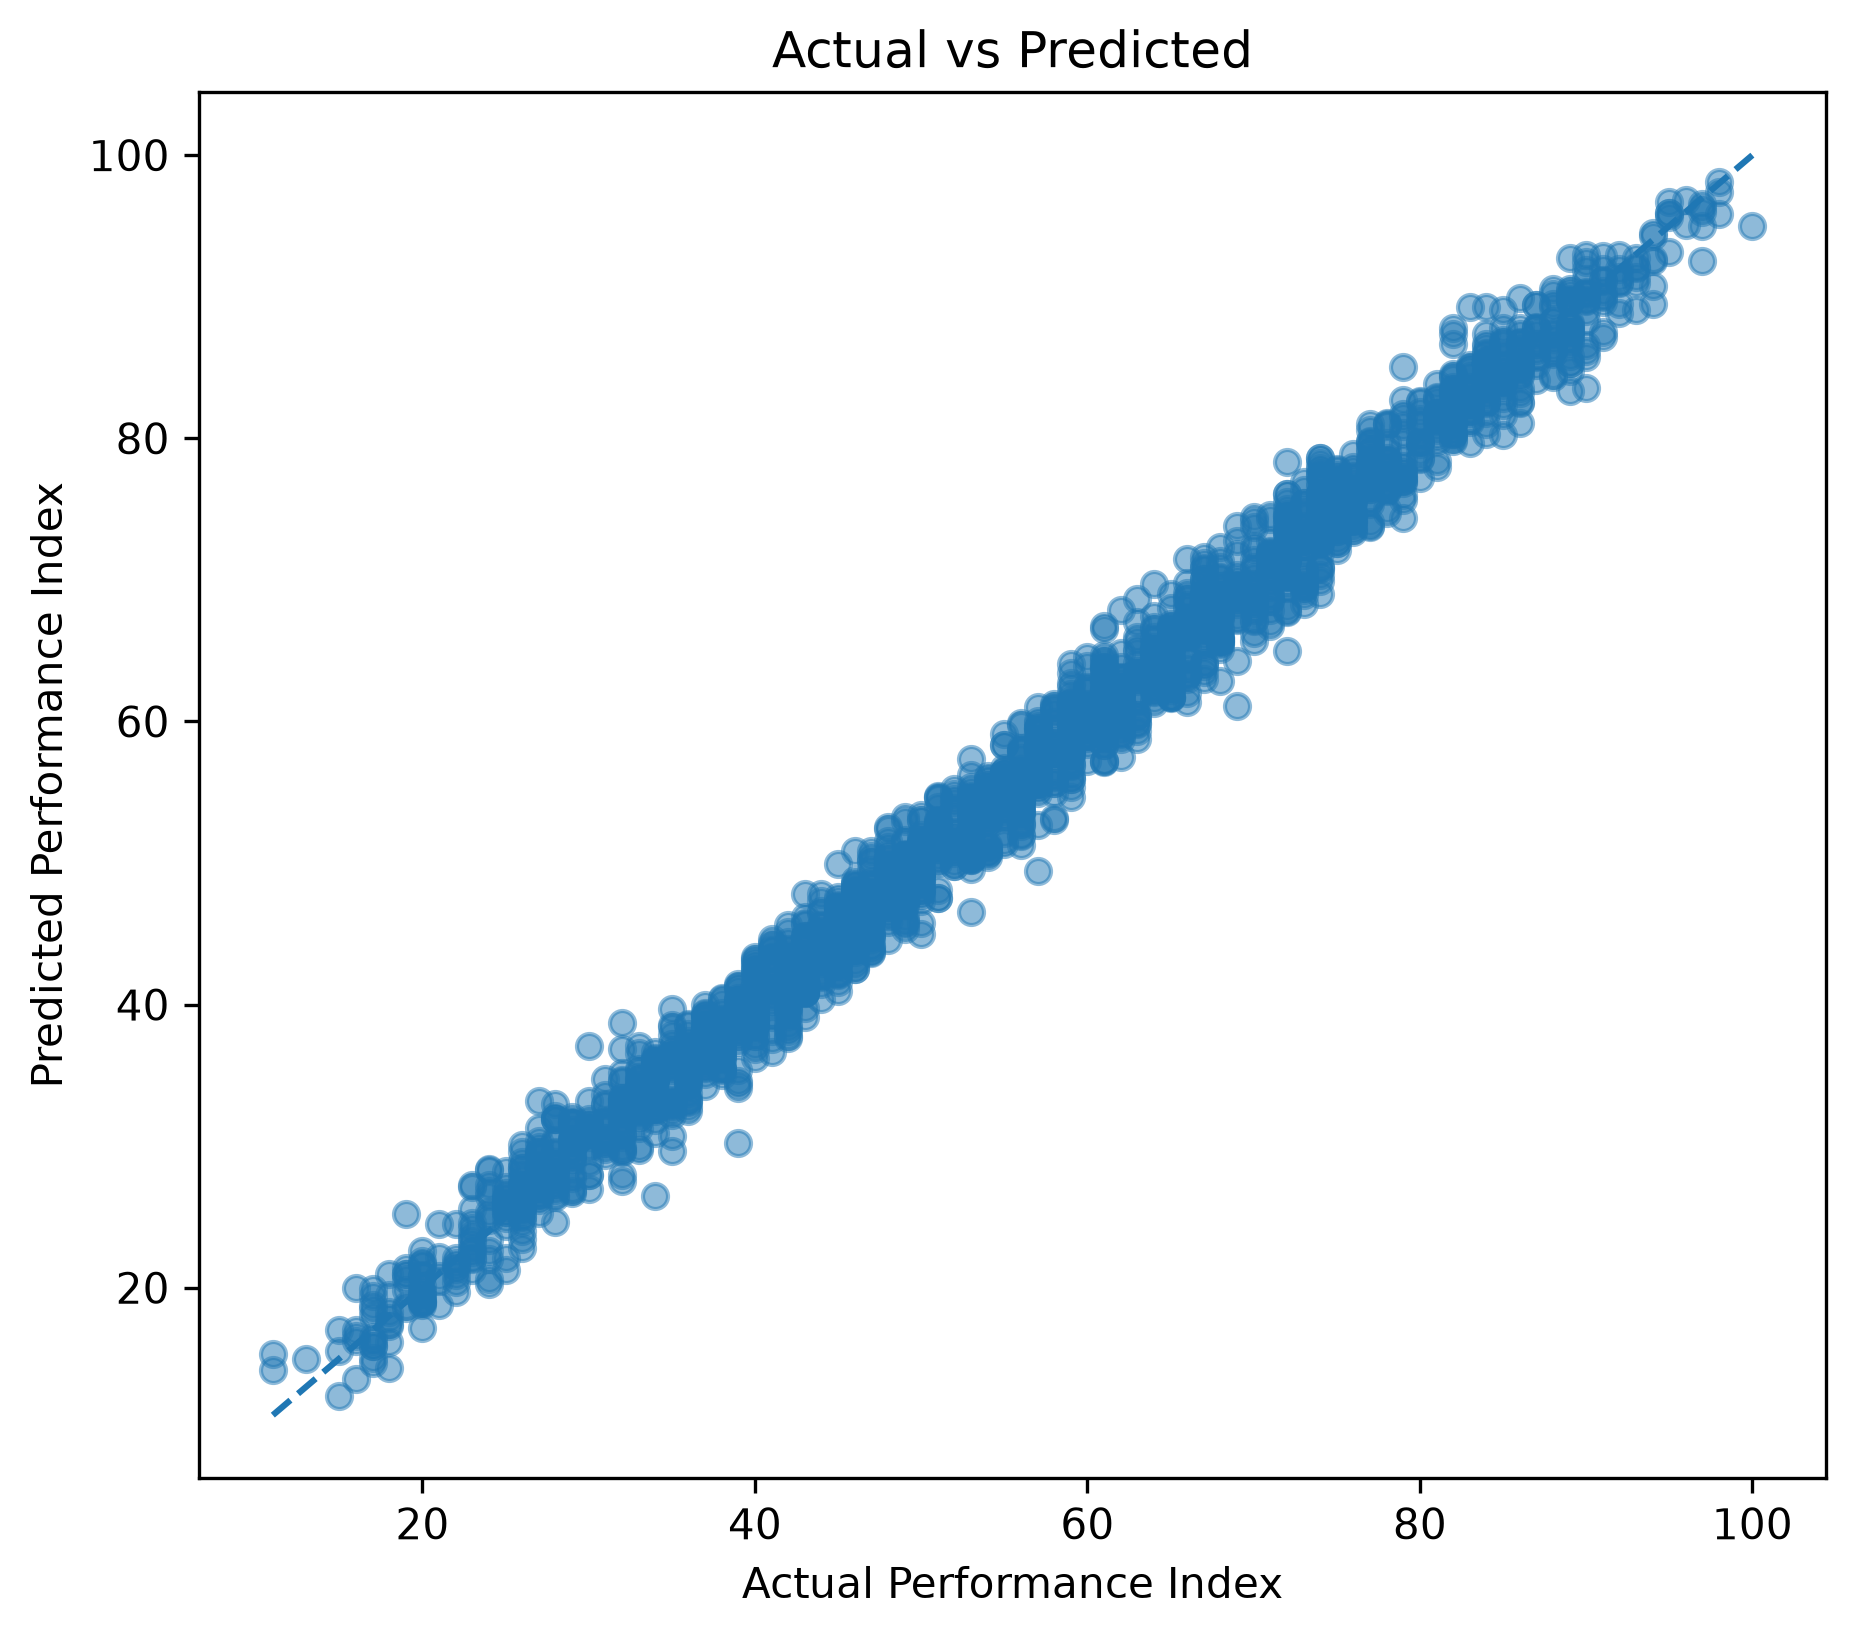

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6), dpi=300)

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted")

plt.show()

#### Residual vs Predicted plot

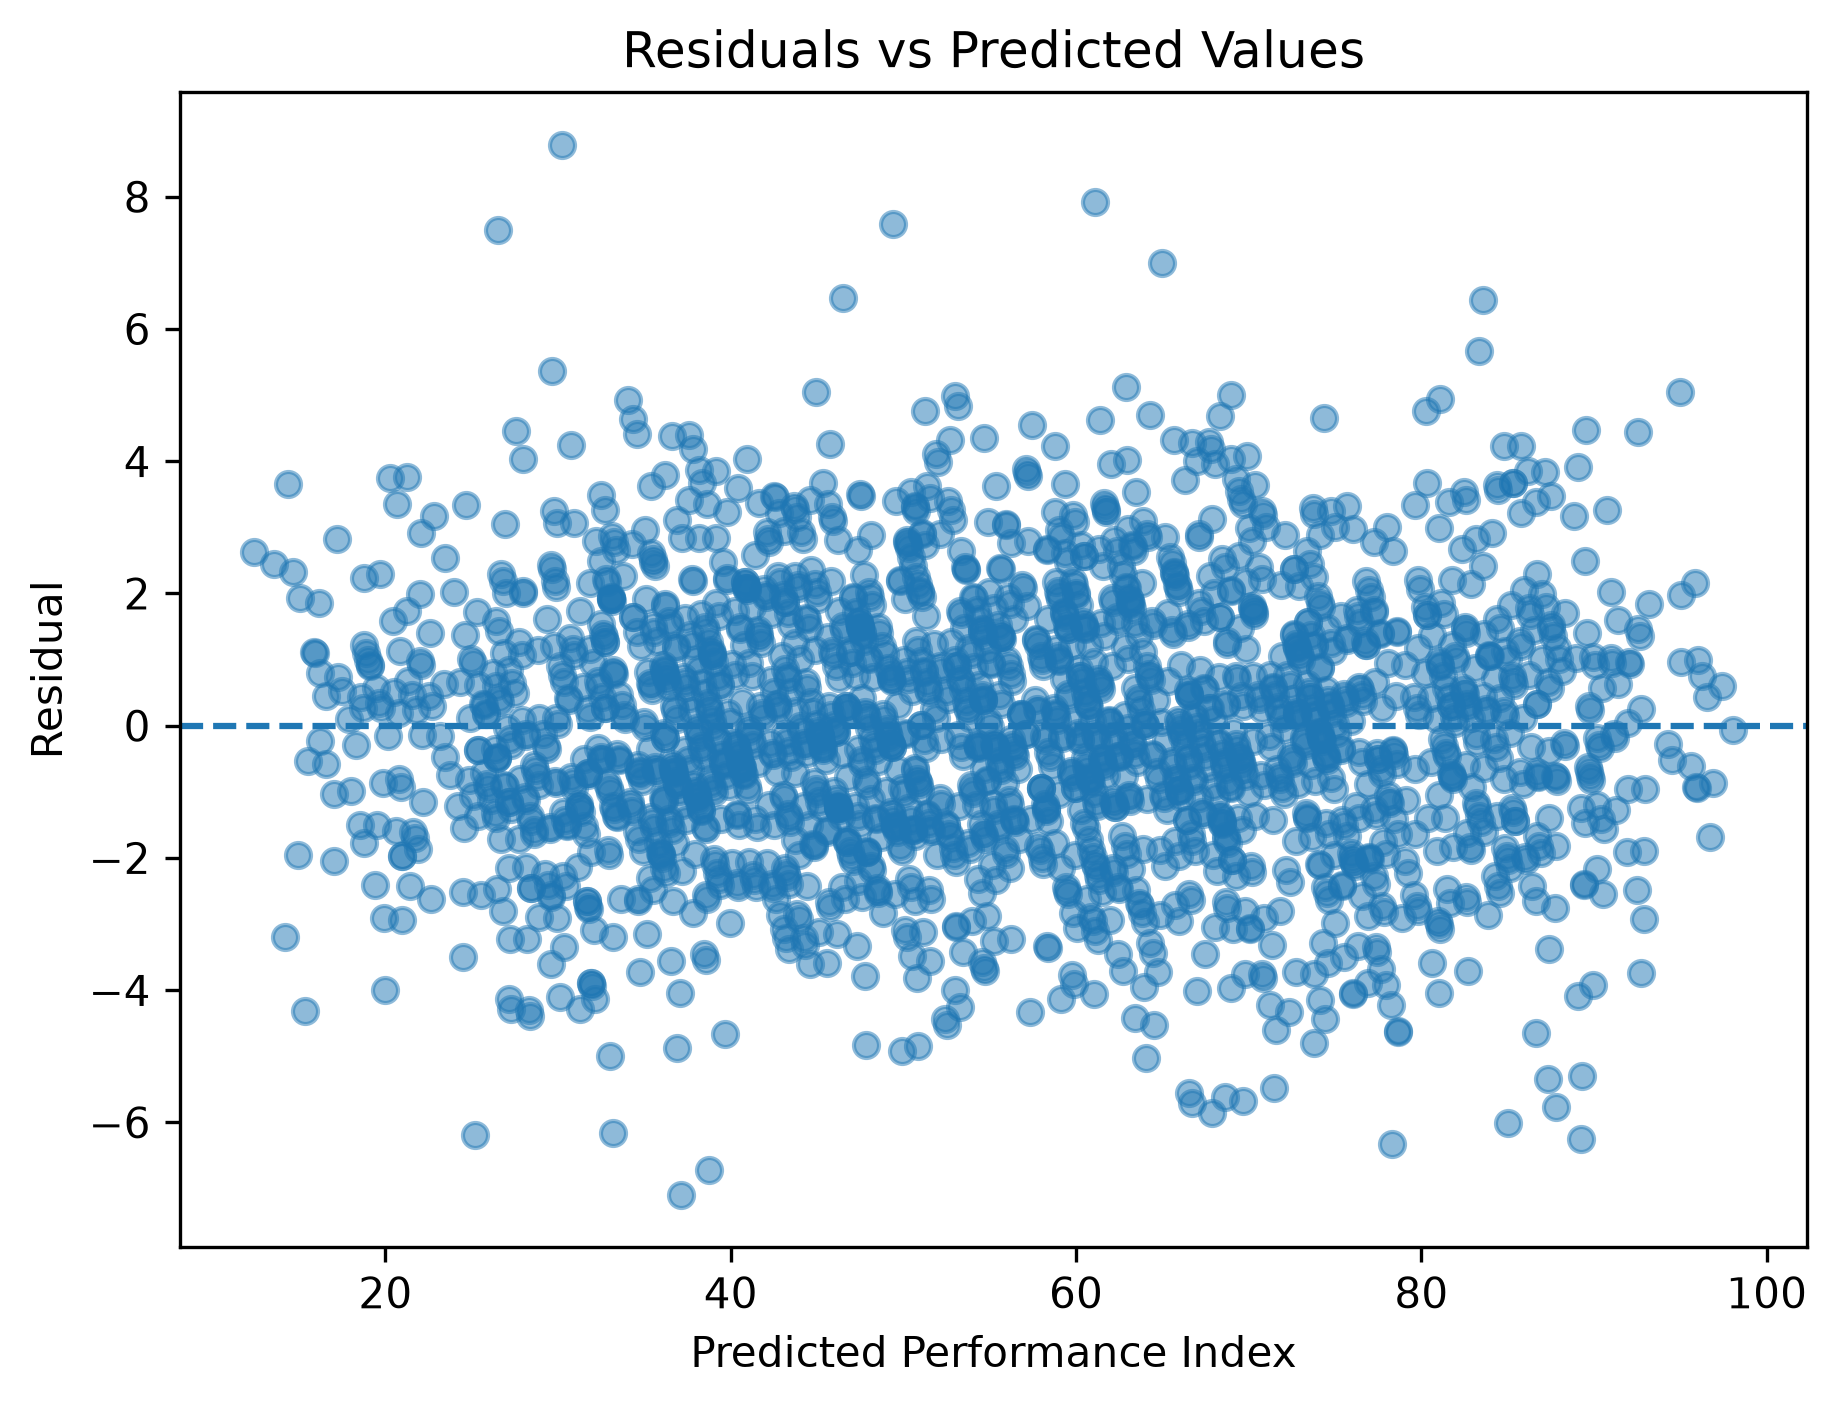

In [81]:
plt.figure(figsize=(7, 5), dpi=300)

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Performance Index")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")

plt.show()

#### Residual distribution

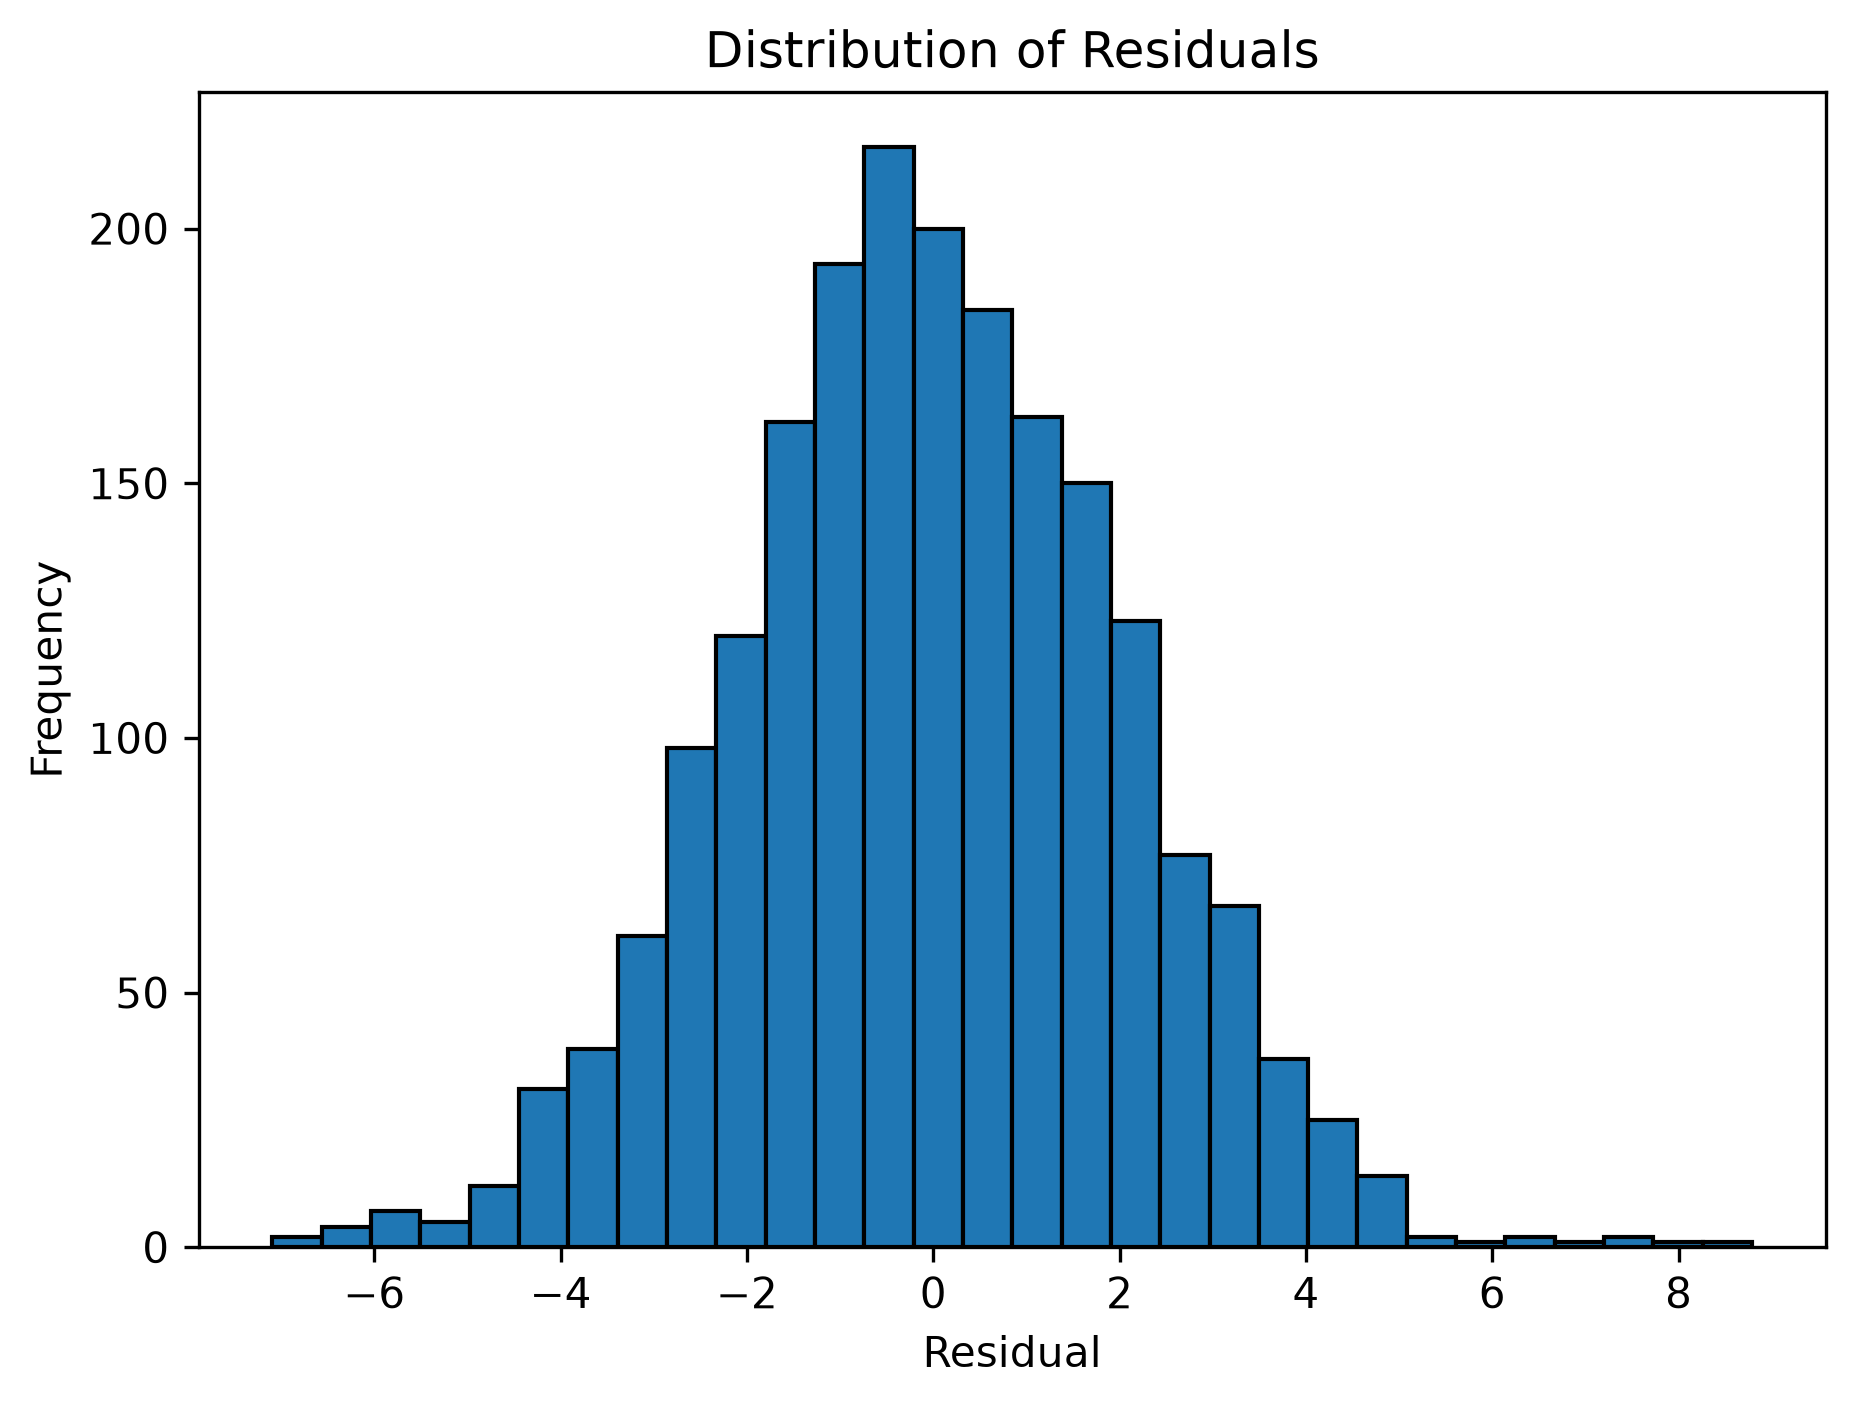

In [84]:
plt.figure(figsize=(7, 5), dpi=300)

plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()